# 01 - Exploratory Data Analysis su GTSRB

Questo notebook esplora il dataset GTSRB nella versione classification prima di costruire baseline, fine-tuning e pipeline sperimentale.

L'obiettivo e' raccogliere osservazioni su distribuzione delle classi, dimensioni delle immagini, qualita' visiva e implicazioni per trasformazioni e metriche.

## Setup

Importiamo le librerie essenziali e definiamo seed, device e percorsi principali.

In [1]:
from collections import Counter
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision.transforms.v2 as T
from torchvision.datasets import GTSRB

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

notebook_dir = Path.cwd()
lab_root = notebook_dir.parent if notebook_dir.name == "exercise_2_gtsrb_classification" else Path("DLA_LAB1")
data_root = lab_root / "_data"

print(f"Device selezionato: {device}")
print(f"Cartella dati: {data_root.resolve()}")

Device selezionato: cuda
Cartella dati: C:\Users\franc\Desktop\Git_Hub_Deep_Learning-Applications_Francesco_Beraldi\DLA_LAB1\_data


## Caricamento del dataset

Carichiamo train e test set con una trasformazione minima, evitando normalizzazione e crop in questa fase per osservare i dati nel modo piu' diretto possibile.

In [2]:
base_transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
])

train_dataset = GTSRB(
    root=str(data_root),
    split="train",
    transform=base_transform,
    download=True,
)
test_dataset = GTSRB(
    root=str(data_root),
    split="test",
    transform=base_transform,
    download=True,
)

print(f"Campioni train: {len(train_dataset)}")
print(f"Campioni test: {len(test_dataset)}")

Campioni train: 26640
Campioni test: 12630


### Osservazioni

- Il dataset contiene 26.640 immagini di addestramento e 12.630 di test (circa 68% train e 32% test).
- Si tratta degli split ufficiali del benchmark; il test set viene mantenuto separato e usato soltanto per la valutazione finale.

## Ispezione dei primi campioni

Controlliamo tipo, shape e label di alcuni elementi per capire la struttura effettiva restituita da `torchvision.datasets.GTSRB`.

In [3]:
for index in range(5):
    image, label = train_dataset[index]
    print(
        f"Indice {index}: tipo={type(image).__name__}, "
        f"shape={tuple(image.shape)}, label={label}"
    )

Indice 0: tipo=Image, shape=(3, 30, 29), label=0
Indice 1: tipo=Image, shape=(3, 30, 30), label=0
Indice 2: tipo=Image, shape=(3, 30, 30), label=0
Indice 3: tipo=Image, shape=(3, 31, 31), label=0
Indice 4: tipo=Image, shape=(3, 32, 30), label=0


### Osservazioni

- Le immagini sono caricate come oggetti `Image` di torchvision e hanno 3 canali colore (RGB).
- La risoluzione cambia da un'immagine all'altra ed è molto bassa (ad esempio 30x29 o 32x30 pixel).
- Poiché i modelli richiedono input a dimensione fissa per poter elaborare i batch di dati, sarà necessario definire un'operazione di resize o crop prima dell'addestramento.

## Campioni casuali

Visualizziamo un insieme casuale di immagini per osservare variabilita' visiva, qualita', rotazioni, luminosita' e possibili ambiguita' tra classi.

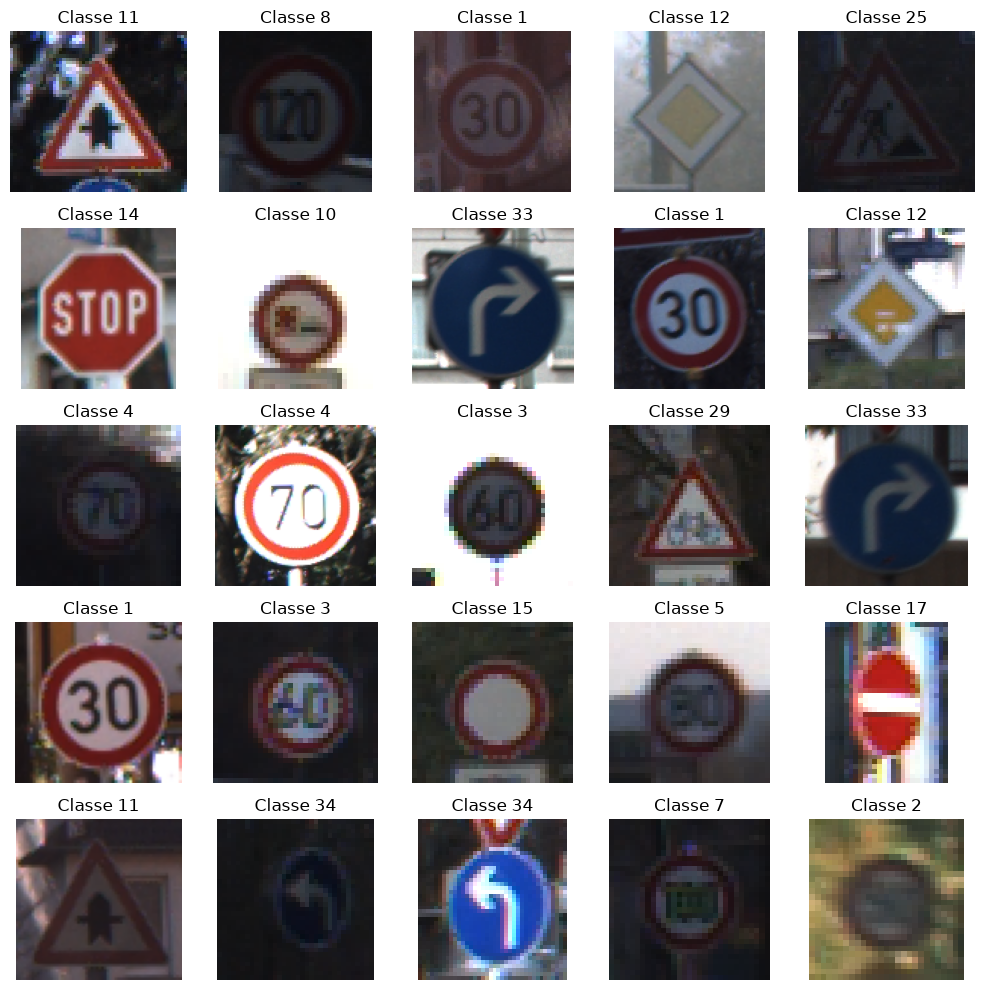

In [4]:
num_samples = 25
sample_indices = np.random.choice(len(train_dataset), size=num_samples, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for axis, index in zip(axes.ravel(), sample_indices):
    image, label = train_dataset[int(index)]
    axis.imshow(image.permute(1, 2, 0))
    axis.set_title(f"Classe {label}")
    axis.axis("off")

plt.tight_layout()

### Osservazioni

- **Qualità e dettaglio**: Le immagini presentano livelli di dettaglio molto eterogenei; a seconda del campione estratto, alcune immagini risultano nitide e definite, mentre altre sono sgranate, sfocate o a bassissima risoluzione.
- **Esposizione e illuminazione**: Si osservano forti variazioni nelle condizioni di luce. Diversi campioni possono risultare scuri o sottoesposti (quasi in ombra), mentre altri presentano problemi di sovraesposizione, forte contrasto o riflessi di luce che slavano i colori del segnale.
- **Angolazione e prospettiva**: I segnali non sono sempre perfettamente frontali; si riscontrano spesso lievi rotazioni, inclinazioni e distorsioni prospettiche dovute all'inquadratura reale.
- **Implicazioni**: Questa forte variabilità suggerisce che l'uso di data augmentation (come la regolazione del contrasto, della luminosità e leggere rotazioni geometriche) sarà importante per rendere il modello più robusto alle reali condizioni ambientali.

## Distribuzione delle classi

Misuriamo quante immagini sono disponibili per ogni classe in train e test set. Questo aiuta a capire se l'accuracy globale puo' nascondere problemi su classi minoritarie.

In [5]:
def count_labels(dataset):
    """Conta le occorrenze delle classi in un dataset GTSRB."""

    return Counter(label for _, label in dataset)


train_counts = count_labels(train_dataset)
test_counts = count_labels(test_dataset)

class_distribution = pd.DataFrame({
    "class_id": sorted(train_counts.keys()),
    "train_count": [train_counts[class_id] for class_id in sorted(train_counts.keys())],
    "test_count": [test_counts.get(class_id, 0) for class_id in sorted(train_counts.keys())],
})

class_distribution.describe()

,class_id,train_count,test_count
count,43.000000,43.000000,43.000000
mean,21.000000,619.534884,293.720930
std,12.556539,462.765772,233.442389
min,0.000000,150.000000,60.000000
25%,10.500000,240.000000,90.000000
50%,21.000000,420.000000,180.000000
75%,31.500000,960.000000,450.000000
max,42.000000,1500.000000,750.000000


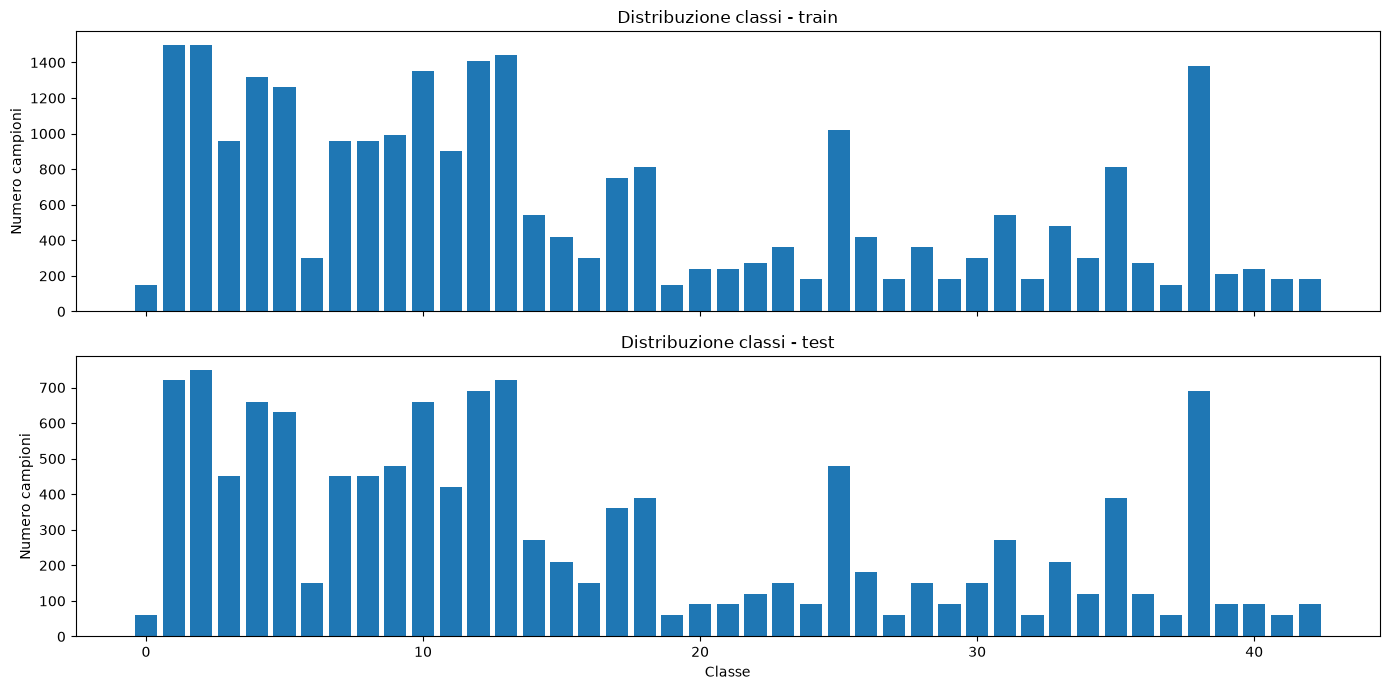

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].bar(class_distribution["class_id"], class_distribution["train_count"])
axes[0].set_title("Distribuzione classi - train")
axes[0].set_ylabel("Numero campioni")

axes[1].bar(class_distribution["class_id"], class_distribution["test_count"])
axes[1].set_title("Distribuzione classi - test")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Numero campioni")

plt.tight_layout()

### Osservazioni

- **Forte sbilanciamento delle classi**: Esiste una marcata disparità tra le classi. Nel training set, la classe con meno campioni ne ha solo 150, mentre la più frequente ne ha 1500 (un rapporto di 10:1). La deviazione standard molto alta (circa 463 per il train) conferma questa forte variabilità.
- **Coerenza tra gli split ufficiali**: Train e test mostrano proporzioni per classe simili. Questa osservazione descrive i dati disponibili, senza assumere una specifica procedura di costruzione degli split.
- **Implicazioni per la metrica**: A causa dello sbilanciamento, l'accuratezza complessiva (Global Accuracy) non sarà sufficiente da sola come metrica di performance, in quanto potrebbe nascondere un comportamento scadente sulle classi minoritarie. Sarà importante monitorare metriche per classe o metriche bilanciate come l'F-1 Score.
- **Implicazioni per il training**: Nelle fasi successive si valuterà l'uso di tecniche per gestire lo sbilanciamento, come una funzione di loss pesata (Weighted Cross-Entropy) o sampler bilanciati nei DataLoader.

## Dimensioni e aspect ratio

Raccogliamo altezza, larghezza e aspect ratio per valutare quanto resize e crop possano modificare il contenuto delle immagini.

In [7]:
def collect_image_metadata(dataset, split_name):
    """Estrae label, altezza, larghezza e aspect ratio da un dataset."""

    rows = []
    for image, label in dataset:
        _, height, width = image.shape
        rows.append({
            "split": split_name,
            "class_id": label,
            "height": height,
            "width": width,
            "aspect_ratio": width / height,
        })
    return pd.DataFrame(rows)


train_metadata = collect_image_metadata(train_dataset, "train")
test_metadata = collect_image_metadata(test_dataset, "test")
image_metadata = pd.concat([train_metadata, test_metadata], ignore_index=True)

image_metadata.groupby("split")[["height", "width", "aspect_ratio"]].describe()

height                                                         width  \
         count       mean        std   min   25%   50%   75%    max    count   
split                                                                          
test   12630.0  50.364450  23.698908  25.0  35.0  43.0  57.0  232.0  12630.0   
train  26640.0  50.365128  23.161523  25.0  35.0  43.0  58.0  225.0  26640.0   

                  ...              aspect_ratio                                \
            mean  ...   75%    max        count      mean       std       min   
split             ...                                                           
test   50.507759  ...  58.0  266.0      12630.0  1.000001  0.080555  0.392857   
train  50.933784  ...  58.0  243.0      26640.0  1.008718  0.072100  0.368132   

                                          
            25%  50%       75%       max  
split                                     
test   0.968750  1.0  1.035714  1.437500  
train  0.972222  1.0  1.044444  1.417808  

[2 rows x 24 columns]

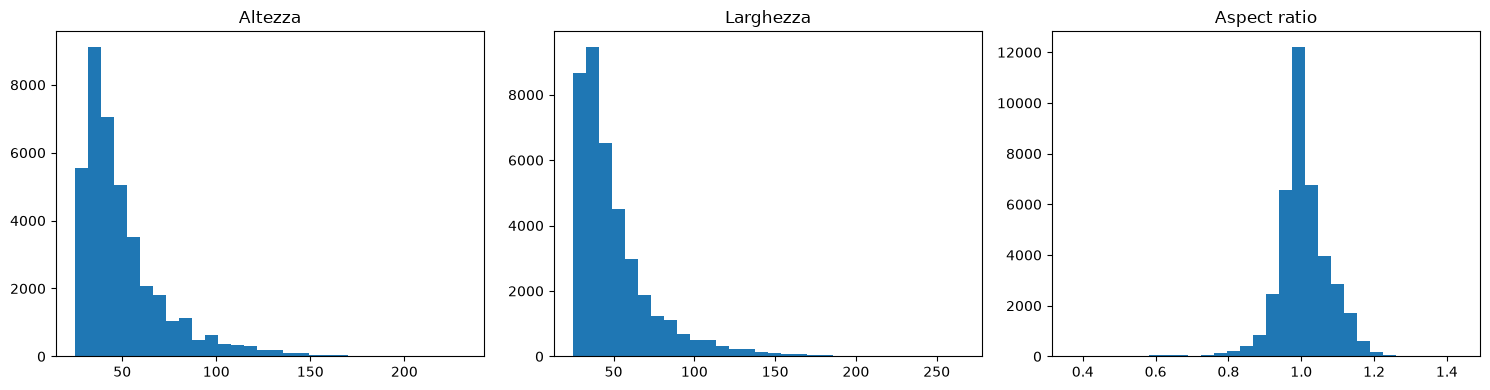

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(image_metadata["height"], bins=30)
axes[0].set_title("Altezza")

axes[1].hist(image_metadata["width"], bins=30)
axes[1].set_title("Larghezza")

axes[2].hist(image_metadata["aspect_ratio"], bins=30)
axes[2].set_title("Aspect ratio")

plt.tight_layout()

### Osservazioni

- **Aspect ratio quasi perfetto**: La media e la mediana dell'aspect ratio sono pari a 1.0 (con una deviazione standard bassissima di ~0.07). Questo indica che quasi tutti i ritagli delle immagini sono quadrati. Di conseguenza, impostare un ridimensionamento ad una forma quadrata (es. 64x64) non introdurrà distorsioni geometriche o deformazioni rilevanti sui segnali.
- **Risoluzione medio-bassa e outlier**: La dimensione media delle immagini è di circa 50x50 pixel, e oltre il 50% delle immagini ha una risoluzione inferiore a 43x43 pixel (il minimo è 25x25). Ci sono tuttavia alcuni rari campioni ad alta risoluzione (fino a oltre 230 pixel).
- **Implicazioni per il resize**: Poiché la stragrande maggioranza delle immagini è molto piccola, fare un resize a dimensioni molto grandi (es. 224x224, tipico di molte architetture preaddestrate) comporterebbe un forte upsampling artificiale che potrebbe non aggiungere informazioni reali. La scelta di una dimensione target intorno a 64x64 pixel rappresenta un ottimo compromesso tra conservazione del dettaglio originario e costo computazionale.
- **Omogeneità train/test**: Le metriche geometriche (medie, deviazioni standard, minimi e massimi) sono pressoché identiche tra train e test set, confermando l'assenza di bias sistematici nella divisione del dataset.

## Esempi per classi selezionate

Visualizziamo alcune classi specifiche per confrontare variabilita' intra-classe e possibili somiglianze tra classi diverse.

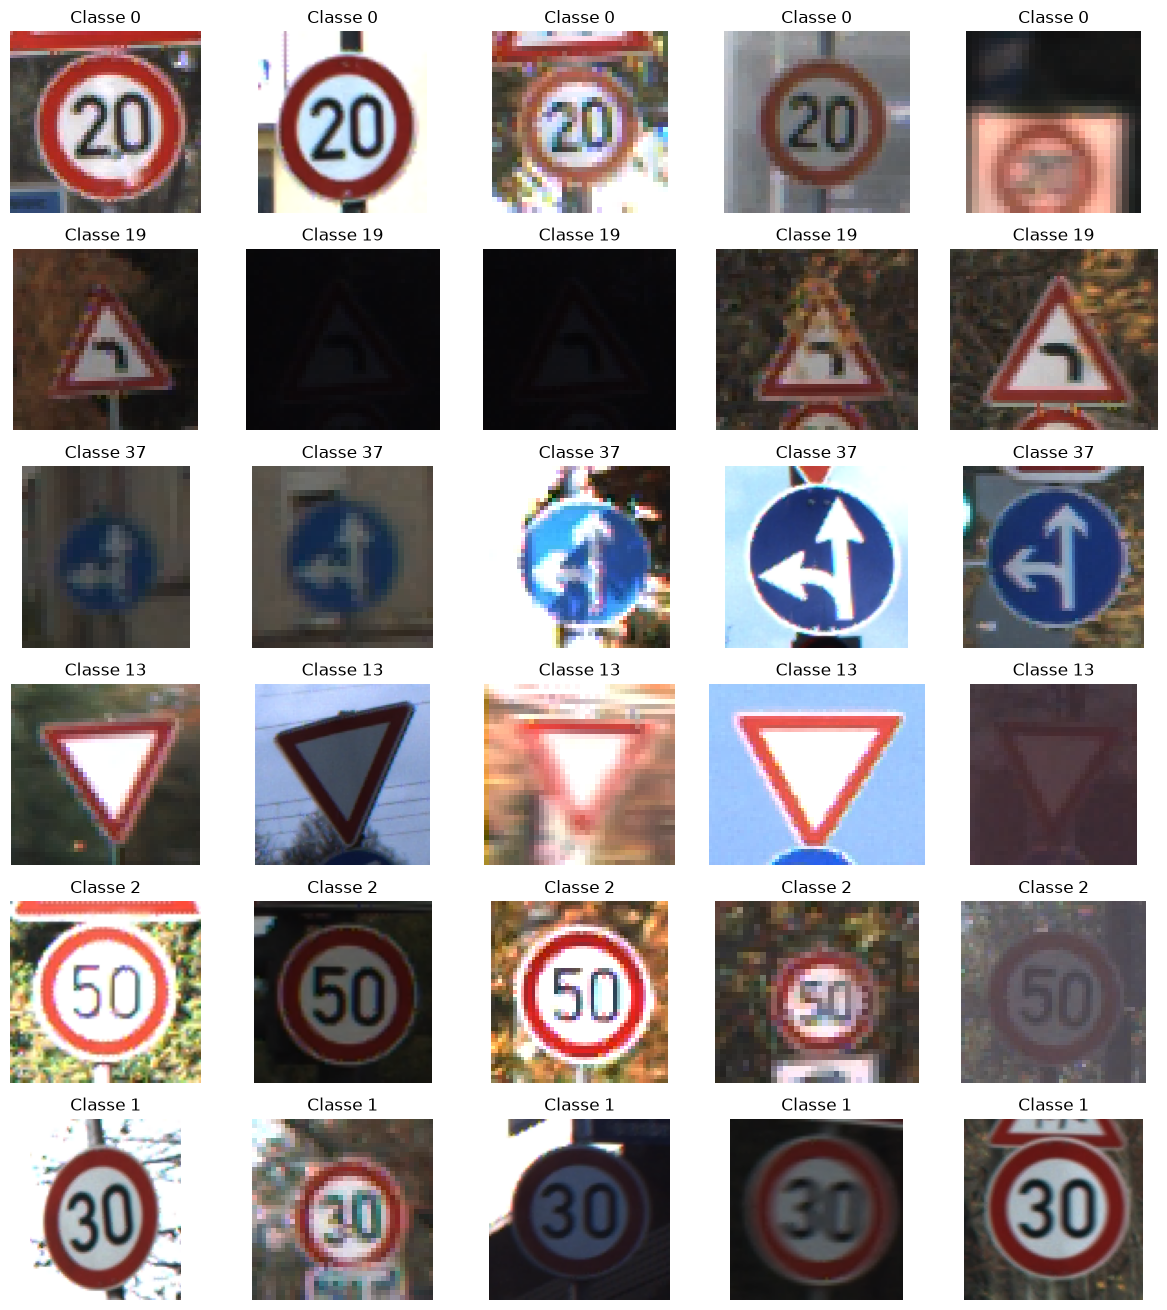

In [9]:
# Selezioniamo le 3 classi meno frequenti e le 3 piu' frequenti per confrontarle visivamente
selected_classes = class_distribution.sort_values("train_count").head(3)["class_id"].tolist()
selected_classes += class_distribution.sort_values("train_count").tail(3)["class_id"].tolist()

fig, axes = plt.subplots(len(selected_classes), 5, figsize=(12, 2.2 * len(selected_classes)))

for row, class_id in enumerate(selected_classes):
    class_indices = [index for index, (_, label) in enumerate(train_dataset) if label == class_id]
    chosen_indices = np.random.choice(class_indices, size=min(5, len(class_indices)), replace=False)
    for col, index in enumerate(chosen_indices):
        image, label = train_dataset[int(index)]
        axes[row, col].imshow(image.permute(1, 2, 0))
        axes[row, col].set_title(f"Classe {label}")
        axes[row, col].axis("off")

plt.tight_layout()

### Osservazioni

- **Forte variabilità intra-classe**: Anche all'interno della stessa classe di segnale stradale, l'aspetto visivo dei campioni cambia drasticamente per diversi fattori:
  - **Condizioni di luce ed esposizione**: Alcuni campioni sono quasi completamente neri (sottoesposizione estrema), mentre altri presentano riflessi accecanti della luce solare (sovraesposizione).
  - **Errori di allineamento e ritaglio**: In diversi casi, il cartello stradale non è centrato, è tagliato ai bordi o include ampie porzioni di sfondo non inerenti al segnale.
  - **Distorsioni, rumore e sfocatura**: Molte immagini mostrano un forte rumore digitale, artefatti di compressione o sfocatura da movimento (motion blur).
- **Implicazioni**: Il modello non dovrà basarsi su feature rigide o cromatiche assolute per classificare, ma dovrà imparare forme e pattern geometrici strutturali invarianti a queste alterazioni. Questo rende indispensabile l'uso di data augmentation per simulare queste variazioni.

## Trasformazioni candidate

Confrontiamo visivamente alcune trasformazioni plausibili per la baseline. Questa sezione serve solo a valutarne l'effetto qualitativo, non ad addestrare modelli.

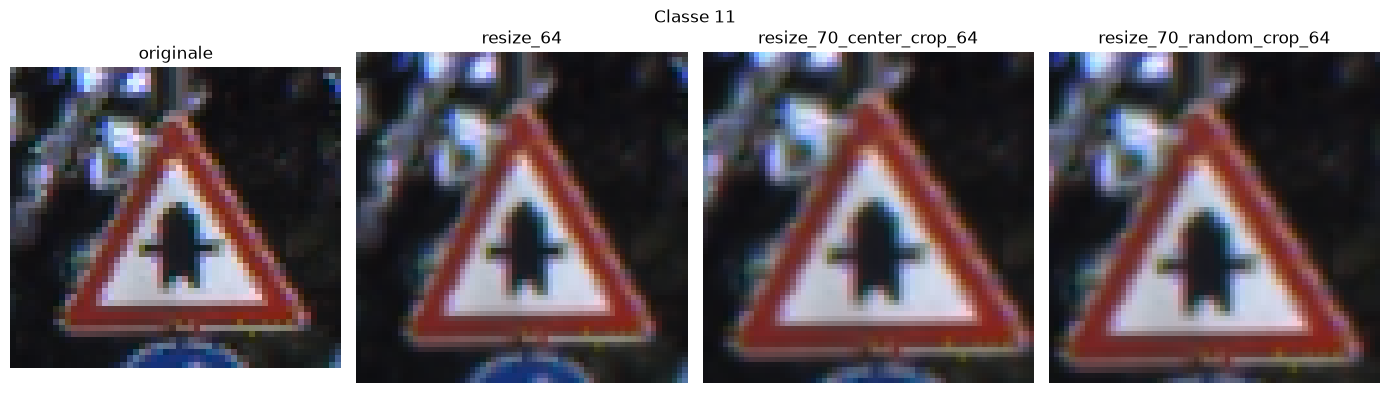

In [10]:
preview_index = int(sample_indices[0])
preview_image, preview_label = train_dataset[preview_index]

candidate_transforms = {
    "originale": lambda image: image,
    "resize_64": T.Resize((64, 64)),
    "resize_70_center_crop_64": T.Compose([T.Resize(70), T.CenterCrop((64, 64))]),
    "resize_70_random_crop_64": T.Compose([T.Resize(70), T.RandomCrop((64, 64))]),
}

fig, axes = plt.subplots(1, len(candidate_transforms), figsize=(14, 4))
for axis, (name, transform) in zip(axes, candidate_transforms.items()):
    transformed_image = transform(preview_image)
    axis.imshow(transformed_image.permute(1, 2, 0))
    axis.set_title(name)
    axis.axis("off")

plt.suptitle(f"Classe {preview_label}")
plt.tight_layout()

### Osservazioni

- Un semplice ridimensionamento diretto (`resize_64`) può alterare leggermente l'aspect ratio dell'immagine.
- L'accoppiata di resize a 70 pixel e crop a 64x64 pixel preserva meglio le proporzioni originarie del segnale.
- Come best practice per la validazione e il test, viene valutato l'uso del `CenterCrop` al posto del `RandomCrop` (anche se si tratta di una differenza di pochi pixel), così da rendere la valutazione deterministica e non influenzata da ritagli casuali.

## Sintesi finale

### Osservazioni principali

- **Bilanciamento del dataset**: Il dataset è ripartito in modo stratificato tra training (26.640) e test (12.630). Tuttavia, esiste un forte sbilanciamento tra le 43 classi (fino a un rapporto di 10:1).
- **Proprietà geometriche**: L'aspect ratio è quasi esattamente 1.0 (quadrato). La risoluzione media delle immagini è bassa (circa 50x50, con oltre la metà delle immagini inferiore a 43x43 pixel).
- **Variabilità intra-classe**: I campioni risentono di forti variazioni di luminosità (zone d'ombra ed esposizione solare diretta), sfuocature, artefatti di compressione e ritagli disallineati.

### Implicazioni per i notebook successivi

- **Scelta delle metriche**: L'accuratezza globale non è sufficiente a causa dello sbilanciamento delle classi. Occorrerà monitorare la F1-Score e analizzare le performance per-classe.
- **Dimensioni di input**: Risoluzioni moderate come 64x64 pixel rappresentano il miglior compromesso. Poiché oltre il 50% delle immagini ha dimensioni inferiori a 43x43, un ridimensionamento a risoluzioni elevate (es. 224x224) provocherebbe un forte upsampling artificiale delle immagini, allungando i tempi di calcolo senza aggiungere dettagli reali.
- **Data Augmentation**: Sarà opportuno implementare variazioni di contrasto, luminosità e rotazioni per addestrare modelli robusti alle alterazioni visive riscontrate.

### Decisioni operative provvisorie

- Adottare un resize seguito da crop (64x64 pixel) per uniformare gli input.
- Utilizzare `RandomCrop` nel train per fare data augmentation ed evitare overfitting, e `CenterCrop` nel test set per garantire valutazioni stabili, deterministiche e ripetibili.
- Valutare strategie come loss pesate o sampler bilanciati per gestire lo sbilanciamento delle classi.